# 03 - Filtrado

Notebook reservado para la Fase 3: diseño y prueba de filtros en frecuencia.

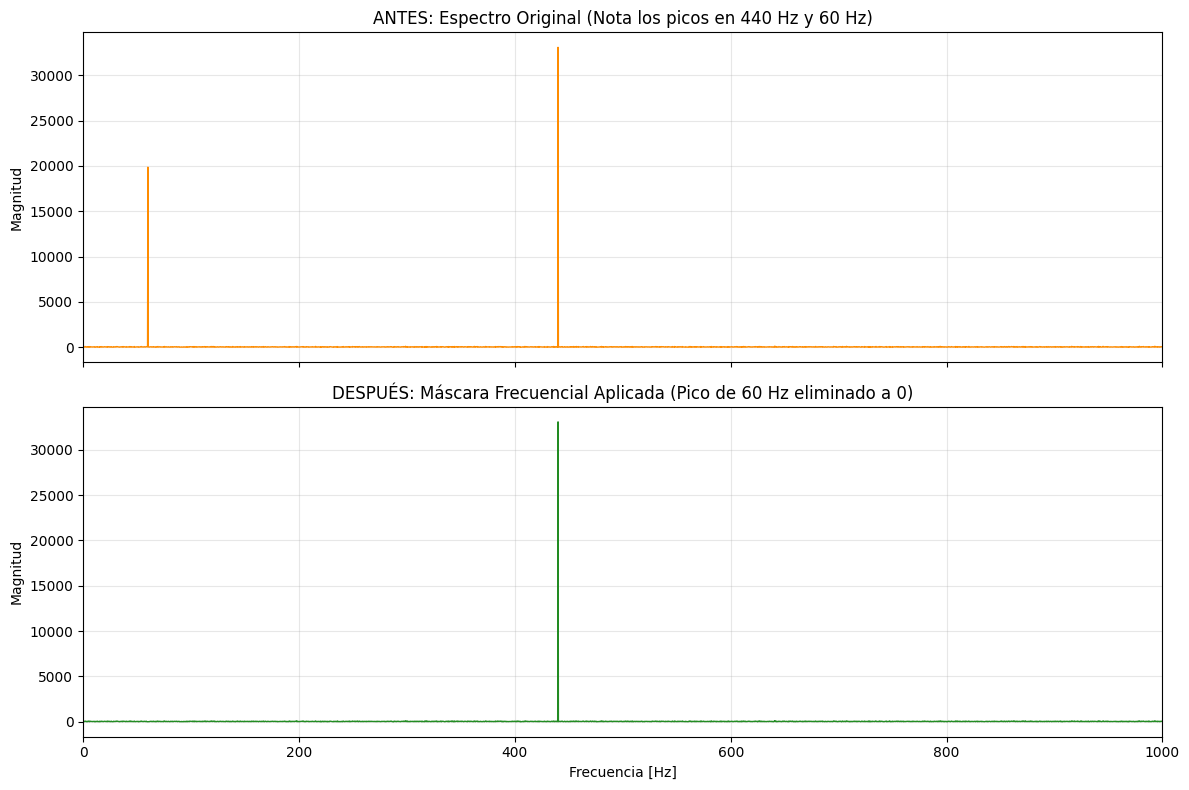

In [3]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq

# 1. Conectamos tu arquitectura modular
sys.path.append("..")
from src.audio_loader import load_audio
from src.filters import apply_notch_mask

# 2. Cargamos el audio sintético (con los picos de 440 Hz y 60 Hz)
AUDIO_PATH = Path("../data/raw/PruebaAN.wav")
senal_ruidosa, sample_rate = load_audio(AUDIO_PATH)

# 3. FASE 2: Transformada
N = len(senal_ruidosa)
espectro_ruidoso = fft(senal_ruidosa)
frecuencias = fftfreq(N, 1 / sample_rate) # Reconstruimos el eje X (Frecuencias)

# 4. FASE 3: Diseño de Máscara (El filtro)
espectro_limpio = apply_notch_mask(espectro_ruidoso, center_hz=60.0, bandwidth_hz=2.0, sample_rate=sample_rate)

# --- INICIO DE LA VISUALIZACIÓN ---
# Para graficar, solo tomamos la mitad positiva del espectro
mitad = N // 2
freqs_plot = frecuencias[:mitad]
mag_ruido = np.abs(espectro_ruidoso[:mitad])
mag_limpio = np.abs(espectro_limpio[:mitad])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Gráfica Original
ax1.plot(freqs_plot, mag_ruido, color='darkorange', linewidth=1)
ax1.set_title("ANTES: Espectro Original (Nota los picos en 440 Hz y 60 Hz)")
ax1.set_ylabel("Magnitud")
ax1.set_xlim(0, 1000) # Hacemos zoom en las frecuencias bajas
ax1.grid(True, alpha=0.3)

# Gráfica con la Máscara
ax2.plot(freqs_plot, mag_limpio, color='forestgreen', linewidth=1)
ax2.set_title("DESPUÉS: Máscara Frecuencial Aplicada (Pico de 60 Hz eliminado a 0)")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Magnitud")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# --- FIN DE LA VISUALIZACIÓN ---

# 5. FASE 4: Reconstrucción
senal_limpia = np.real(ifft(espectro_limpio))

In [4]:
import soundfile as sf

# 1. Guardamos el audio original (con zumbido) para tenerlo a la mano
ruta_ruido = Path("../data/processed/1_audio_con_zumbido.wav")
sf.write(ruta_ruido, senal_ruidosa, sample_rate)

# 2. Guardamos nuestro audio filtrado matemáticamente
ruta_limpio = Path("../data/processed/2_audio_limpio_fft.wav")
sf.write(ruta_limpio, senal_limpia, sample_rate)

print(f"Audios exportados en la carpeta 'data/processed/'.")
print("¡Ve a tu explorador de archivos, ponte audífonos y escucha la diferencia!")

Audios exportados en la carpeta 'data/processed/'.
¡Ve a tu explorador de archivos, ponte audífonos y escucha la diferencia!
